In [1]:
import pandas as pd
from pathlib import Path

# from posydon.popsyn.binarypopulation import BinaryPopulation
# from posydon.binary_evol.binarystar import BinaryStar
# from posydon.binary_evol.singlestar import SingleStar
from posydon.popsyn.synthetic_population import Population
# from posydon.popsyn.synthetic_population import PopulationRunner
# import astropy.units as u
# 
# import os
# import shutil
# from posydon.config import PATH_TO_POSYDON

from POSYDONHRDiagramModule import HR_Diagram

import matplotlib.pyplot as plt

import random as rand 

from collections import Counter

DataPath = Path().resolve().parent / 'Data'


In [2]:
cols = ['time', 'step_names', 'state', 'event', 'S1_state', 'S2_state', 'S1_mass', 'S2_mass', 'orbital_period']
finCols = [
    'orbital_period_f',
    'eccentricity_f',
    'state_f',

    'S1_state_f',
    'S2_state_f',
    
    'S2_mass_f',
    'S2_log_R_f',
    'S2_log_L_f',


    'S1_mass_f',
    'S1_log_R_f',
    'S1_log_L_f'

 ]

initCols = [
    'orbital_period_i',
    'eccentricity_i',
    'state_i',

    'S2_state_i',
    'S2_mass_i',
    'S2_log_R_i',

    'S1_state_i',
    'S1_mass_i',
    'S1_log_R_i'
 ]

In [3]:
def basicColHist(df, var:str, title:str|None = None, xLabel:str|None = None, saveFig:bool = False) -> None:

    fig, ax = plt.subplots(figsize = (8,5))
    
    ax.hist(df[var], bins = 50)

    if title == None: 
        title = f'{var} of BH-Sol systems at S1 SN'
    ax.set_title(title)    

    if xLabel == None:
        xLabel = var 
    ax.set_xlabel(xLabel)
    ax.set_ylabel('count')

    if saveFig == True:
        plt.savefig(title.replace(' ', '_')) 
    
    return plt.show() 

def xVsY(df, xvar:str, yvar:str, title:str|None = None, xLabel:str|None = None, yLabel:str|None = None, saveFig:bool = False) -> None:

    fig, ax = plt.subplots(figsize = (8,5))
    
    ax.scatter(df[xvar],df[yvar])

    if title == None: 
        title = f'{xvar} vs {yvar} of BH-Sol systems at S1 SN'
    ax.set_title(title)    

    if xLabel == None:
        xLabel = xvar 
    if yLabel == None:
        yLabel = yvar 
    ax.set_xlabel(xLabel)
    ax.set_ylabel(yLabel)

    if saveFig == True:
        plt.savefig(title.replace(' ', '_')) 
    
    return plt.show() 
 

In [4]:
pop = Population(str(DataPath / 'SunLikeStar_Filt' / 'BH_Sol_Filtered_1e+00_Zsun_population.h5'))

In [5]:
bhSolRows = pd.read_csv(DataPath /'SunLikeStar_Filt' / 'BH_Sol_Filtered_1e+00_Zsun_population.csv')

In [6]:
pop.calculate_formation_channels()

In [7]:
Counter(pop.formation_channels['channel'])

Counter({'ZAMS_oCE1_CC1_oRLO2_CC2_maxtime_END': 35,
         'ZAMS_oCE1_CC1_oRLO2_maxtime_END': 7,
         'ZAMS_oCE1_CC1_END': 3,
         'ZAMS_oRLO1_CC1_oRLO2_CC2_FAILED': 1})

In [8]:
pOneline = pop.oneline.select()
pHistory = pop.history.select()

In [9]:
bhSolRows[cols]

,time,step_names,state,event,S1_state,S2_state,S1_mass,S2_mass,orbital_period
0,4.498900e+09,step_SN,detached,NaN,BH,H-rich_Core_H_burning,2.679673,2.998272,1.494220
1,8.381730e+09,step_SN,detached,NaN,BH,H-rich_Core_H_burning,4.517730,2.945927,1.884652
2,9.548856e+09,step_SN,detached,NaN,BH,H-rich_Core_H_burning,3.141908,2.671987,2.740360
3,2.025330e+09,step_SN,detached,NaN,BH,H-rich_Core_H_burning,2.667703,1.613518,0.796016
4,8.824689e+09,step_SN,detached,NaN,BH,H-rich_Core_H_burning,3.118031,2.971203,3.317456
5,9.934345e+09,step_SN,detached,NaN,BH,H-rich_Core_H_burning,3.746899,2.079317,6.844816
6,9.226441e+09,step_SN,detached,NaN,BH,H-rich_Core_H_burning,3.621245,1.854338,7.859836
7,3.143854e+08,step_SN,detached,NaN,BH,H-rich_Core_H_burning,4.164533,2.635615,52.749603
8,8.256869e+09,step_SN,detached,NaN,BH,H-rich_Core_H_burning,4.515033,2.891355,15.899186
9,7.629761e+09,step_SN,detached,NaN,BH,H-rich_Core_H_burning,3.932408,2.700722,14.974814


In [27]:
pHistory.loc[16]

,state,event,time,orbital_period,eccentricity,lg_mtransfer_rate,step_names,step_times,S1_state,S1_mass,...,S2_he_core_mass,S2_he_core_radius,S2_co_core_mass,S2_co_core_radius,S2_center_h1,S2_center_he4,S2_surface_h1,S2_surface_he4,S2_surf_avg_omega_div_omega_crit,S2_spin
binary_index,,,,,,,,,,,,,,,,,,,,,
16,detached,ZAMS,3.735535e+09,4390.052803,0.560283,NaN,initial_cond,0.000000,H-rich_Core_H_burning,14.878710,...,0.000000,NaN,NaN,NaN,0.715500,0.270300,NaN,NaN,NaN,NaN
16,RLO1,oCE1,3.752248e+09,5187.051662,0.560283,-2.291095,step_HMS_HMS,0.082653,H-rich_Core_He_depleted,7.811906,...,0.000000,0.000000,0.000000,0.000000,0.707259,0.278235,0.684465,0.301290,0.965948,0.845181
16,detached,NaN,3.752248e+09,26.162221,0.000000,NaN,step_CE,0.000165,stripped_He_Core_He_depleted,7.047758,...,0.000000,0.000000,0.000000,0.000000,0.707259,0.278235,0.684465,0.301290,0.965948,0.845181
16,detached,CC1,3.752248e+09,25.899428,0.000000,NaN,step_detached,0.378036,stripped_He_Core_C_depleted,7.187840,...,0.000000,NaN,0.000000,0.000000,0.705245,0.280154,0.715500,0.270271,0.023647,0.665088
16,detached,NaN,3.752248e+09,190.296092,0.736579,NaN,step_SN,0.011185,BH,3.171739,...,0.000000,NaN,0.000000,0.000000,0.705245,0.280154,0.715500,0.270271,0.023647,0.665088
16,RLO2,oRLO2,5.658404e+09,55.988243,0.000000,NaN,step_detached,0.801546,BH,3.171739,...,0.332163,NaN,0.000000,0.000000,0.000000,0.986131,0.700567,0.284620,0.291307,105.143382
16,detached,CC2,6.540987e+09,900.191348,0.000000,-99.000000,step_CO_HMS_RLO,0.064172,BH,4.003186,...,0.454435,0.014529,0.106024,0.002535,0.000000,0.000021,0.699395,0.286625,0.000003,0.000013
16,detached,NaN,6.540987e+09,904.149485,0.000000,NaN,step_SN,0.000108,BH,4.003186,...,0.444996,NaN,0.444996,NaN,0.000000,0.000021,NaN,NaN,NaN,0.000000
16,detached,maxtime,1.380000e+10,904.149484,0.000000,NaN,step_dco,0.017756,BH,4.003186,...,0.444996,NaN,0.444996,NaN,0.000000,0.000021,NaN,NaN,0.000000,0.000000


In [11]:
pOneline

,state_i,event_i,time_i,orbital_period_i,eccentricity_i,lg_mtransfer_rate_i,step_names_i,step_times_i,S1_state_i,S1_mass_i,...,interp_class_CO_HMS_RLO,interp_class_CO_HeMS,interp_class_CO_HeMS_RLO,mt_history_HMS_HMS,mt_history_CO_HMS_RLO,mt_history_CO_HeMS,mt_history_CO_HeMS_RLO,FAILED,WARNING,metallicity
binary_index,,,,,,,,,,,,,,,,,,,,,
0,detached,ZAMS,4.487391e+09,4028.254542,0.357737,NaN,initial_cond,0.0,H-rich_Core_H_burning,18.338584,...,stable_MT,NaN,NaN,Unstable RLOF during postMS,Last stable RLOF during postMS,NaN,NaN,0,1,1.0
1,detached,ZAMS,8.370801e+09,3905.179808,0.084004,NaN,initial_cond,0.0,H-rich_Core_H_burning,19.435080,...,stable_MT,NaN,NaN,Unstable RLOF during postMS,Last stable RLOF during postMS,NaN,NaN,0,1,1.0
2,detached,ZAMS,9.537004e+09,4137.423411,0.757557,NaN,initial_cond,0.0,H-rich_Core_H_burning,17.983938,...,stable_MT,NaN,NaN,Unstable RLOF during postMS,Last stable RLOF during postMS,NaN,NaN,0,1,1.0
3,detached,ZAMS,2.010199e+09,4370.857404,0.754004,NaN,initial_cond,0.0,H-rich_Core_H_burning,15.506937,...,NaN,NaN,NaN,Unstable RLOF during postMS,NaN,NaN,NaN,0,1,1.0
4,detached,ZAMS,8.812934e+09,3844.570082,0.455501,NaN,initial_cond,0.0,H-rich_Core_H_burning,18.146652,...,stable_MT,NaN,NaN,Unstable RLOF during postMS,Last stable RLOF during postMS,NaN,NaN,0,1,1.0
5,detached,ZAMS,9.918955e+09,4271.287670,0.824328,NaN,initial_cond,0.0,H-rich_Core_H_burning,15.696276,...,stable_MT,NaN,NaN,Unstable RLOF during postMS,Last stable RLOF during postMS,NaN,NaN,0,1,1.0
6,detached,ZAMS,9.210831e+09,4291.679268,0.458543,NaN,initial_cond,0.0,H-rich_Core_H_burning,15.546078,...,stable_MT,NaN,NaN,Unstable RLOF during postMS,Last stable RLOF during postMS,NaN,NaN,0,1,1.0
7,detached,ZAMS,2.996557e+08,4035.130603,0.664716,NaN,initial_cond,0.0,H-rich_Core_H_burning,16.311274,...,stable_MT,NaN,NaN,Unstable RLOF during postMS,Last stable RLOF during postMS,NaN,NaN,0,1,1.0
8,detached,ZAMS,8.242985e+09,3965.440144,0.659758,NaN,initial_cond,0.0,H-rich_Core_H_burning,16.906712,...,stable_MT,NaN,NaN,Unstable RLOF during postMS,Last stable RLOF during postMS,NaN,NaN,0,1,1.0


In [12]:
print(((pOneline['orbital_period_i'].describe()).to_frame().style.format().to_latex(column_format='|l|r|')).replace('_', '\_').replace('%', '\%'))

\begin{tabular}{|l|r|}
 & orbital\_period\_i \\
count & 46.000000 \\
mean & 4060.892944 \\
std & 625.450071 \\
min & 44.352935 \\
25\% & 4006.596501 \\
50\% & 4162.934607 \\
75\% & 4272.853793 \\
max & 4390.052803 \\
\end{tabular}



In [13]:
print(((pOneline['S2_mass_i'].describe()).to_frame().style.format().to_latex(column_format='|l|r|')).replace('_', '\_').replace('%', '\%'))

\begin{tabular}{|l|r|}
 & S2\_mass\_i \\
count & 46.000000 \\
mean & 2.257840 \\
std & 0.543295 \\
min & 1.551266 \\
25\% & 1.884834 \\
50\% & 2.221971 \\
75\% & 2.479485 \\
max & 5.044736 \\
\end{tabular}



In [14]:
print(((pOneline['S1_mass_i'].describe()).to_frame().style.format().to_latex(column_format='|l|r|')).replace('_', '\_').replace('%', '\%'))

\begin{tabular}{|l|r|}
 & S1\_mass\_i \\
count & 46.000000 \\
mean & 16.855898 \\
std & 1.113331 \\
min & 14.878710 \\
25\% & 16.086002 \\
50\% & 16.690346 \\
75\% & 17.766684 \\
max & 19.435080 \\
\end{tabular}



In [15]:
pOneline['eccentricity_i'].describe()

count    46.000000
mean      0.523841
std       0.212769
min       0.075718
25%       0.455824
50%       0.531082
75%       0.682203
max       0.825958
Name: eccentricity_i, dtype: float64

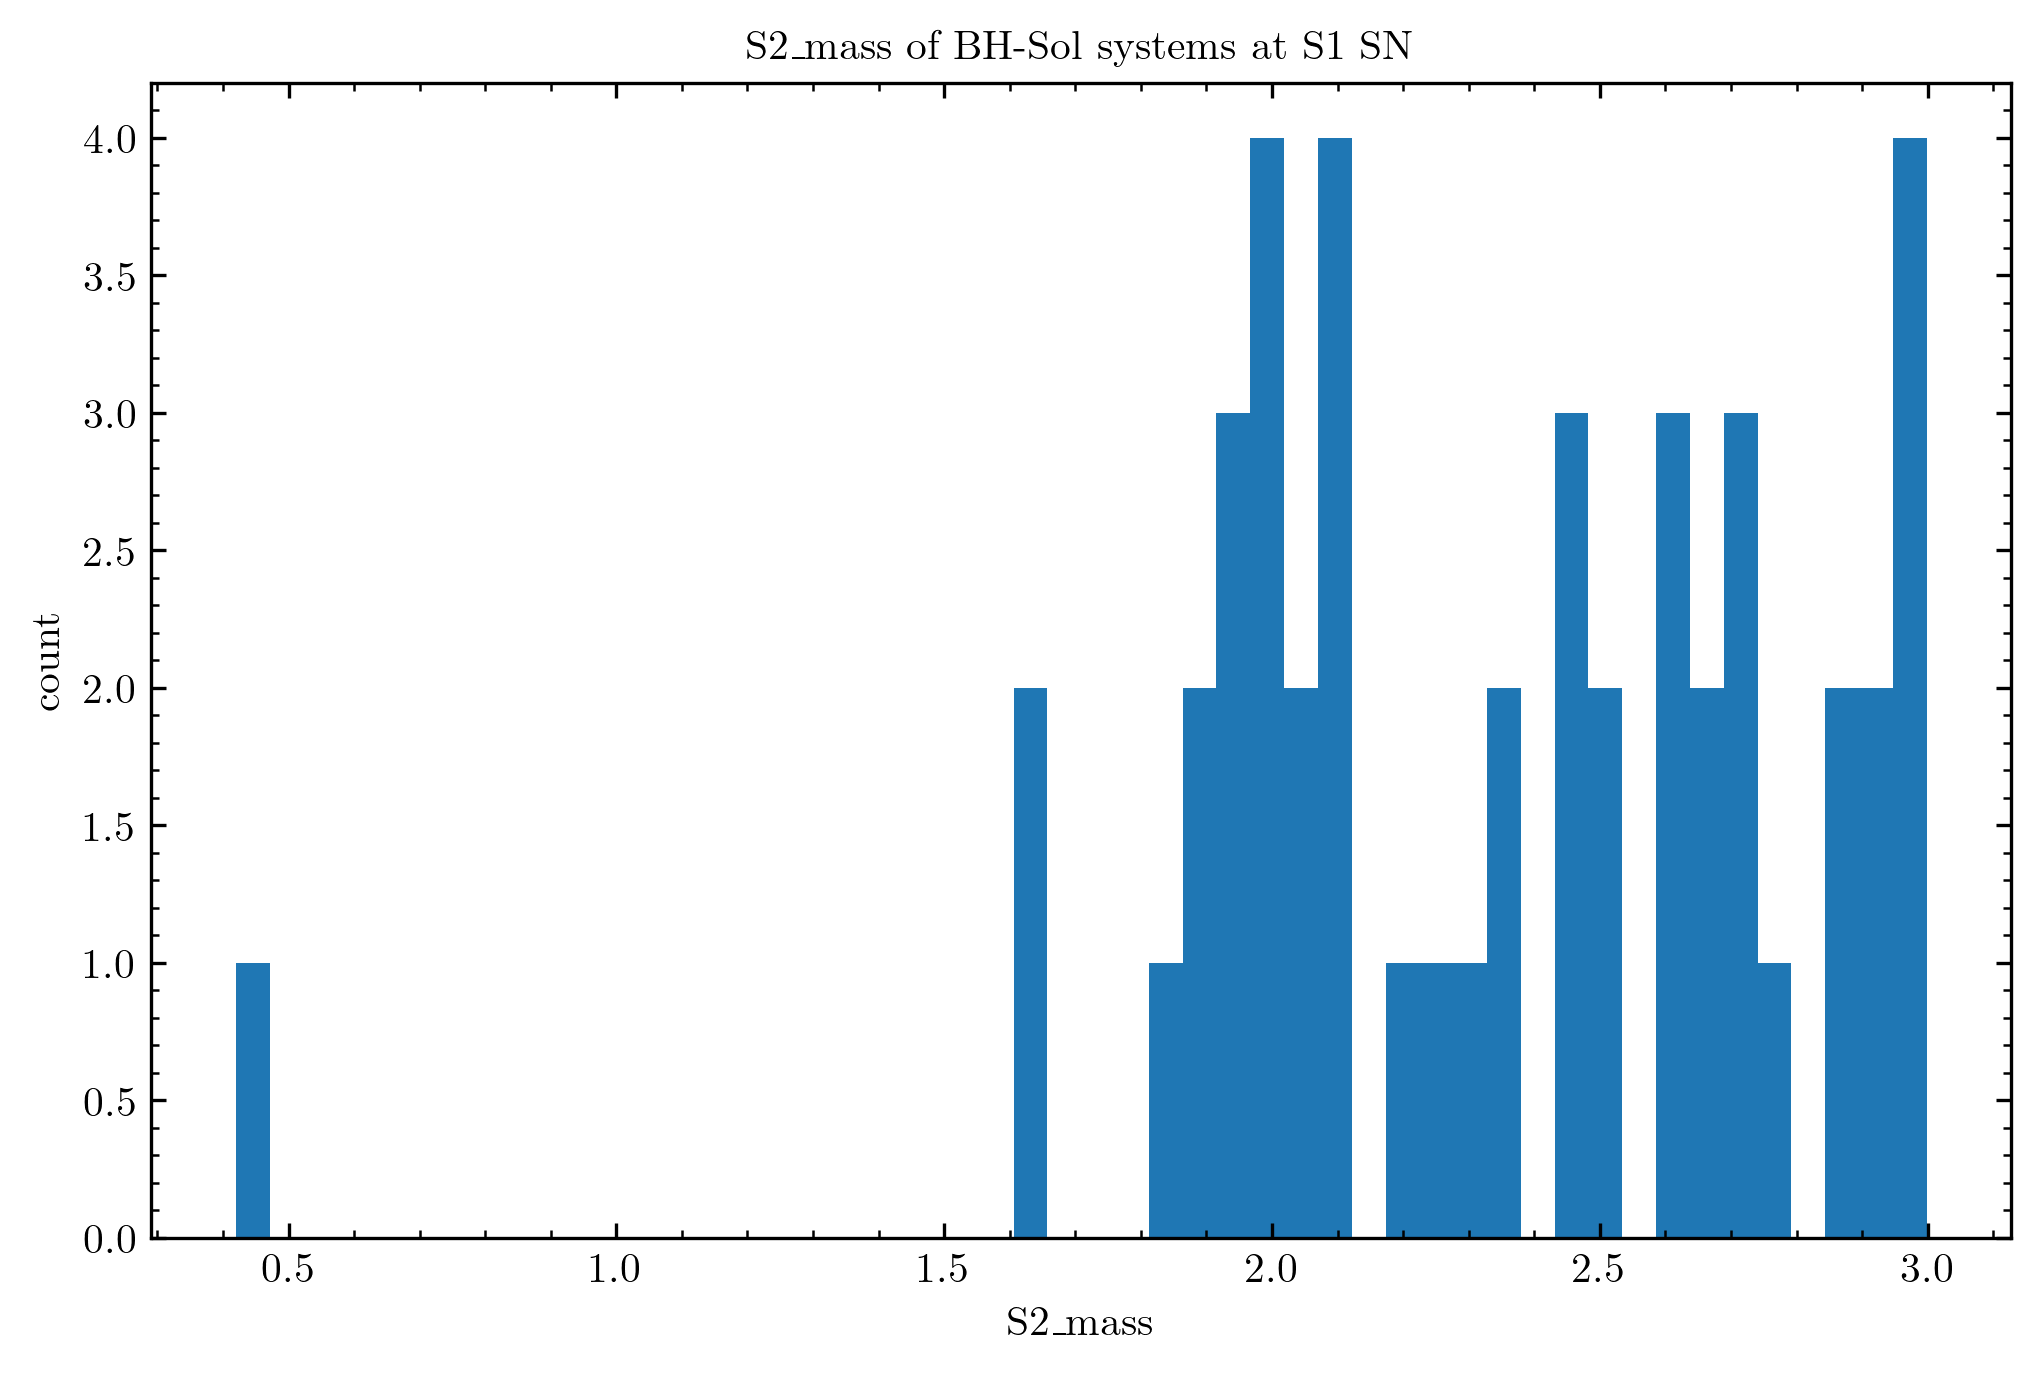

In [16]:
basicColHist(bhSolRows,'S2_mass')

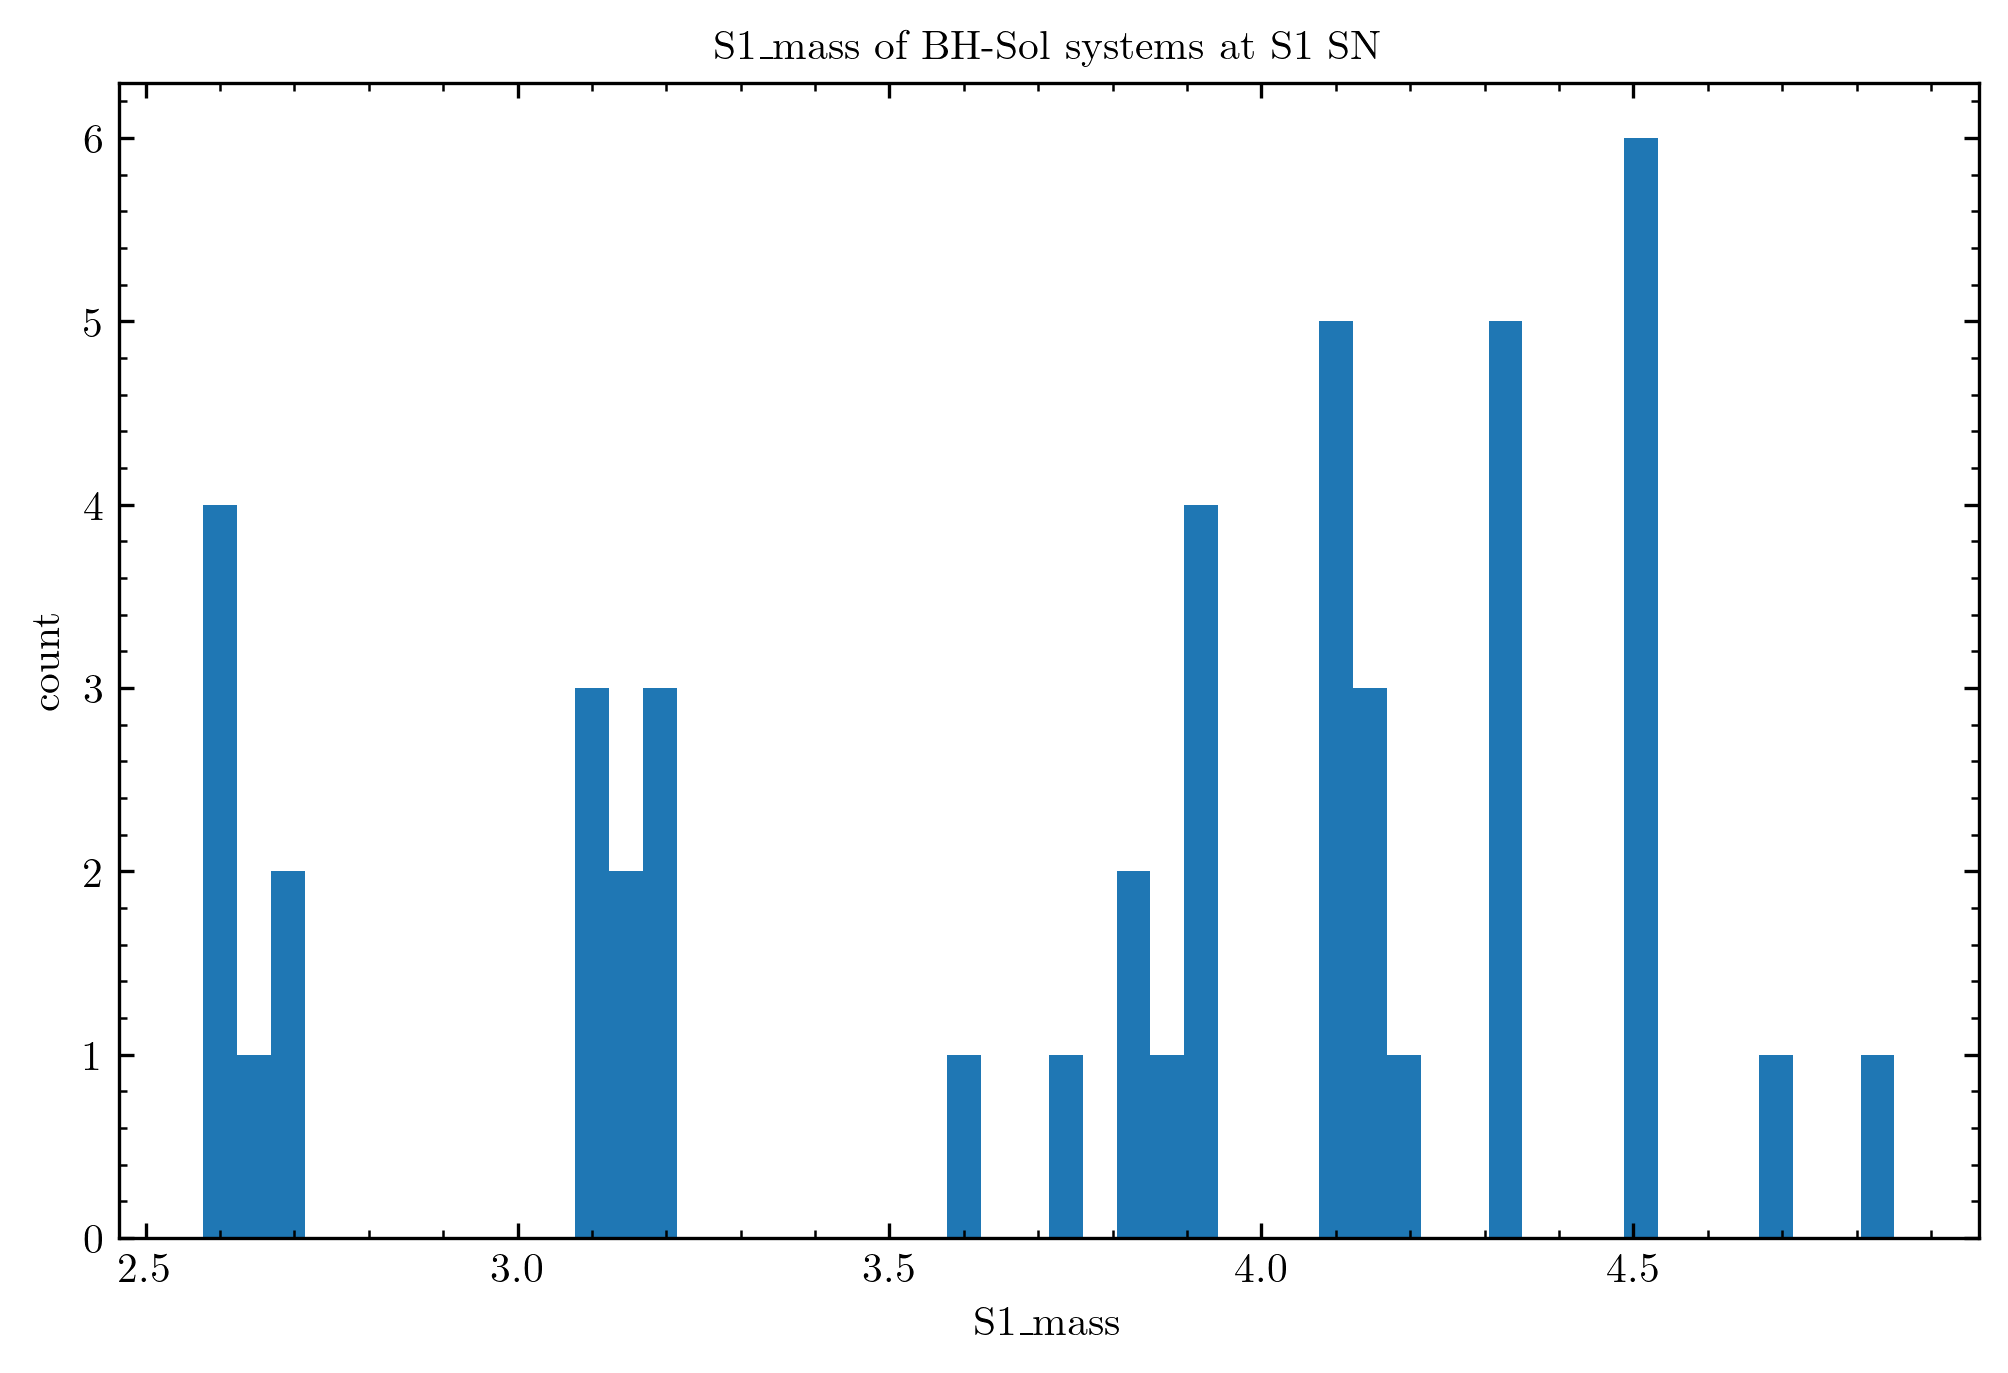

In [17]:
basicColHist(bhSolRows,'S1_mass')

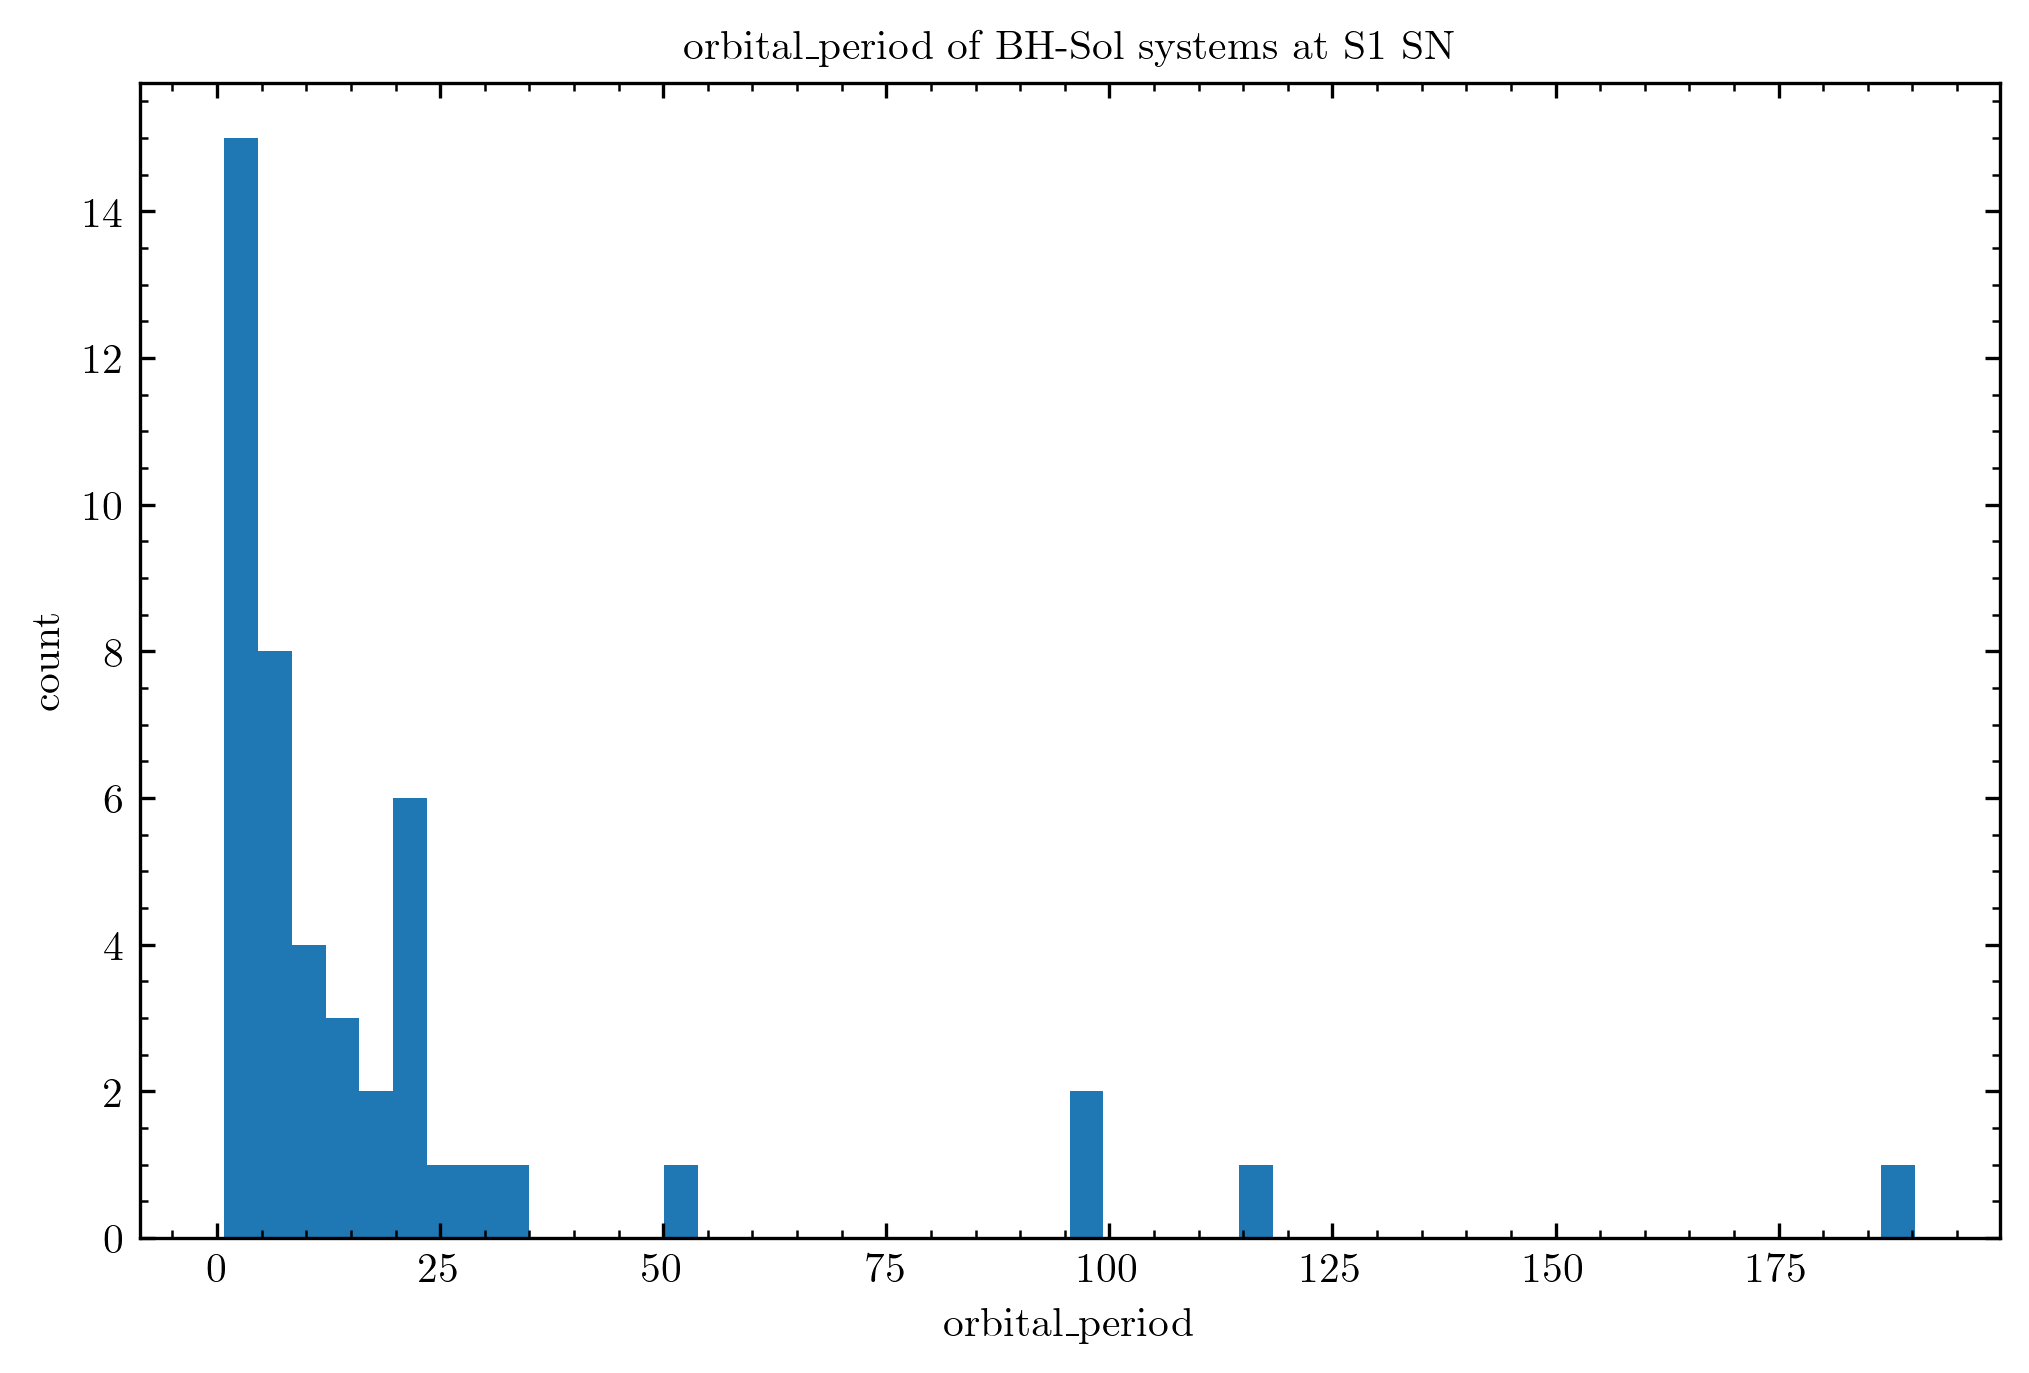

In [18]:
basicColHist(bhSolRows,'orbital_period', saveFig=True)


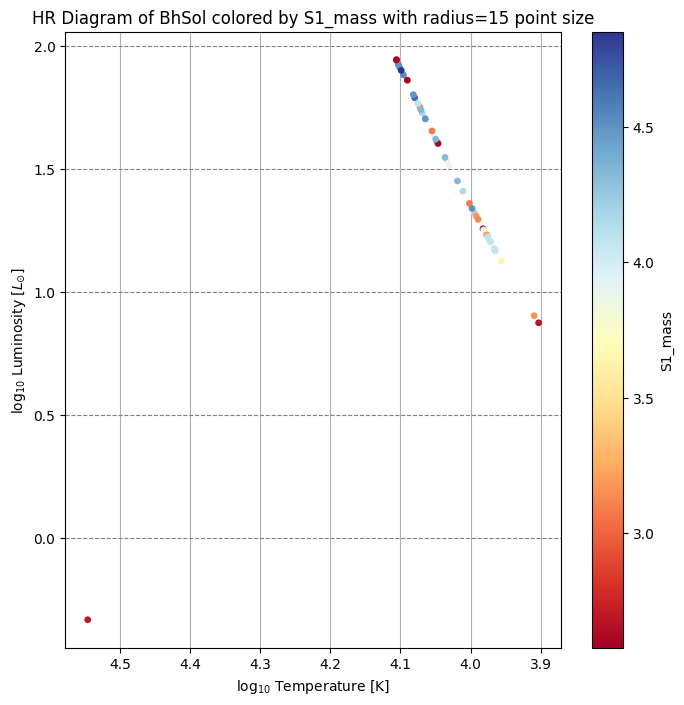

In [19]:
HR_Diagram(bhSolRows,
           'BhSol',
           Star_Radius=15)

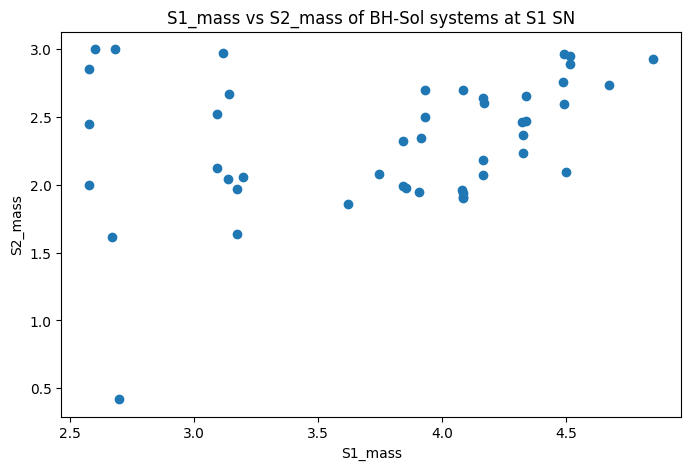

In [20]:
xVsY(bhSolRows, 'S1_mass', 'S2_mass')